# Sentiment analysis on movie reviews

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Extrae el empaquetado directamente en el entorno de ejecución
!tar -xzf /content/drive/MyDrive/ICC/aclImdb_v1.tar.gz -C /content/

In this notebook, we will explore basic NLP techniques to analyze movie reviews using the Large Movie Review Dataset, found in: https://ai.stanford.edu/~amaas/data/sentiment/

In [ ]:
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import os

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import re

In [ ]:
def load_imdb_data(path):
    data = []
    labels = []
    for label in ['pos', 'neg']:
        dir_path = f"{path}/{label}"
        for filename in os.listdir(dir_path):
            with open(f"{dir_path}/{filename}", 'r', encoding='utf-8') as file:
                data.append(file.read())
                labels.append(1 if label == 'pos' else 0)
    return pd.DataFrame({'review': data, 'sentiment': labels})

In [ ]:
# Apuntamos al disco local de la máquina virtual, fuera de Drive
dataset_root = "/content/aclImdb"

# La carga ahora debería tomar solo unos pocos segundos
train_df = load_imdb_data(dataset_root + "/train")
test_df = load_imdb_data(dataset_root + "/test")

## EDA

Let's take a quick look at the data to understand the distribution of sentiments, the length of reviews, and some common words used in positive vs negative reviews.

<Axes: xlabel='sentiment', ylabel='count'>

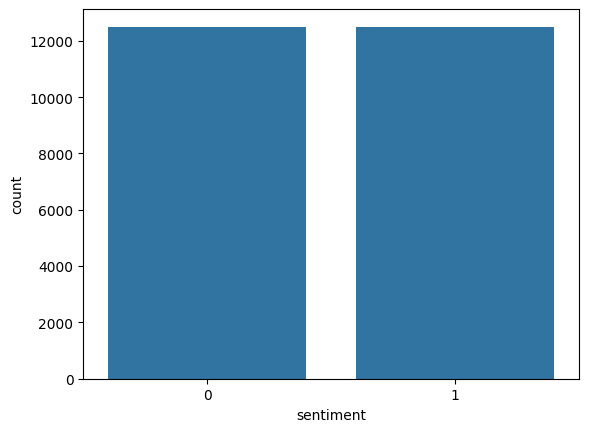

In [ ]:
sns.countplot(x='sentiment', data=train_df)

As we can see, the dataset is balanced with an equal number of positive and negative reviews.

Let's now look at the distribution of review lengths. First compute the length of each review, both in terms of characters and words, and then plot the distributions.

In [ ]:
n_chars = train_df['review'].apply(len)
n_words = train_df['review'].apply(lambda s: len(s.split()))

review_length_df = pd.DataFrame({'chars': n_chars, 'words': n_words, 'sentiment': train_df['sentiment']})
review_length_df.describe().T

,count,mean,std,min,25%,50%,75%,max
chars,25000.0,1325.06964,1003.133670,52.0,702.0,979.0,1614.0,13704.0
words,25000.0,233.78720,173.733032,10.0,127.0,174.0,284.0,2470.0
sentiment,25000.0,0.50000,0.500010,0.0,0.0,0.5,1.0,1.0


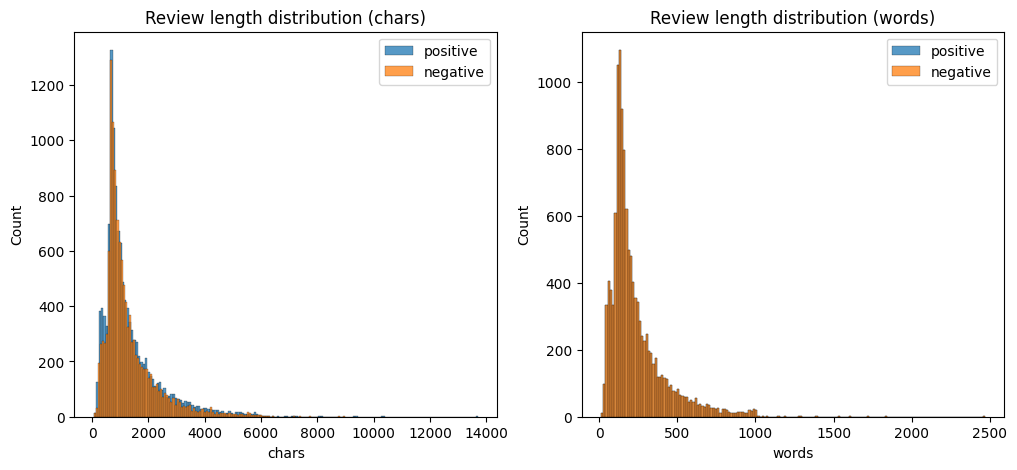

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['chars'], ax=axs[0], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 0]['chars'], ax=axs[0], label='negative')
axs[0].set_title("Review length distribution (chars)")
axs[0].legend()

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='negative')
axs[1].set_title("Review length distribution (words)")
axs[1].legend()

As can be seen, the distribution of review lengths is quite similar for both positive and negative reviews, with most reviews being below 500 words. In terms of characters, most reviews have less than 3000 characters. This can be confirmed with boxplots, which show the "whiskers" of the distribution and any potential outliers.

Text(0.5, 1.0, 'Review length (words) by sentiment')

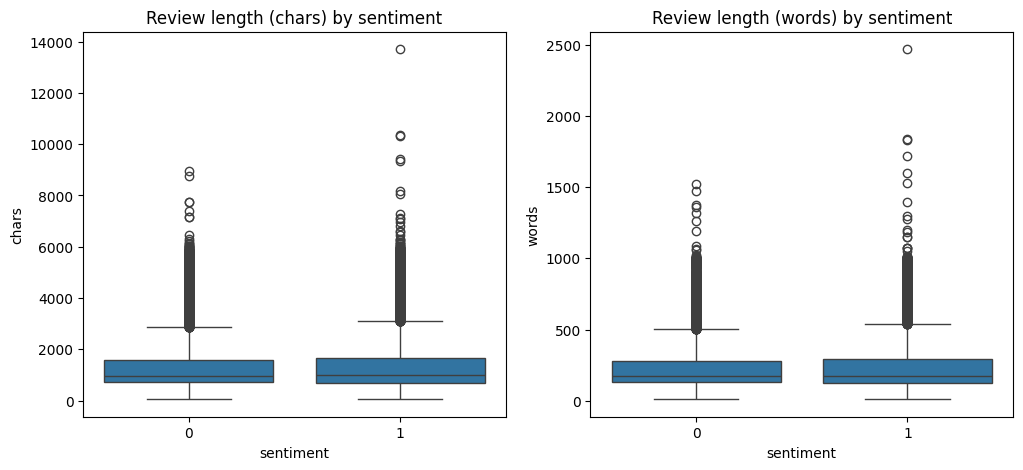

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='sentiment', y='chars', data=review_length_df, ax=axs[0])
axs[0].set_title("Review length (chars) by sentiment")

sns.boxplot(x='sentiment', y='words', data=review_length_df, ax=axs[1])
axs[1].set_title("Review length (words) by sentiment")

In [ ]:
def get_top_words(docs, n=20):
    all_words = ' '.join(docs).split()
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [ ]:
print("Top words in positive reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 1]['review']))

print("\nTop words in negative reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 0]['review']))

Top words in positive reviews:
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'that', 'I', 'it', 'this', '/><br', 'as', 'with', 'was', 'for', 'The', 'but', 'his', 'on']

Top words in negative reviews:
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'I', 'that', 'this', 'it', '/><br', 'was', 'for', 'with', 'as', 'but', 'movie', 'The', 'on']


As we can see, the most common words in both positive and negative reviews are quite similar, with words like "the", "and", "a", "is" appearing frequently. Another issue is that this is case-insensitive, so "the" is treated as different that "The". To get a better idea of common words by sentiment, we can normalize the text by converting it to lowercase and removing any punctuation (and numbers, while we are at it).

In [ ]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
print("Top words in positive reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']]))

print("\nTop words in negative reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']]))

Top words in positive reviews (normalized):
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'br', 'as', 'with', 'for', 'was', 'but', 'film', 'movie', 'his']

Top words in negative reviews (normalized):
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'this', 'i', 'it', 'that', 'br', 'was', 'movie', 'for', 'but', 'with', 'as', 'film', 'on']


While most of the common words are still common stop words, at least we are now getting words like "movie" and "film". However, this still doesn't give us a good idea of which words are more associated with positive vs negative reviews.

To deal with this, we will use the NLTK library to remove stop words.

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stopwords = stopwords.words('english')
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Some of these words are negations, such as "not", "no", "nor", which can be important for sentiment analysis. We will keep these in our list of stop words.

In [ ]:
neg_words = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

stopwords = [w for w in stopwords if w not in neg_words]

Let's redefine our `get_top_words` function to remove stop words before counting the most common words.

In [ ]:
def get_top_words(docs, n=20, exclude=None):
    all_words = ' '.join(docs).split()
    if exclude is not None:
        all_words = [w for w in all_words if w not in exclude]
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [ ]:
# Ensure stopwords are processed in the same way as our documents (lowercased and punctuation removed)
norm_stopwords = set([normalize_text(w) for w in stopwords])

print("Top words in positive reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']], exclude=norm_stopwords))

print("\nTop words in negative reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']], exclude=norm_stopwords))

Top words in positive reviews (no stopwords):
['br', 'film', 'movie', 'not', 'one', 'like', 'good', 'story', 'great', 'time', 'see', 'also', 'really', 'would', 'even', 'first', 'much', 'no', 'people', 'films']

Top words in negative reviews (no stopwords):
['br', 'movie', 'film', 'not', 'one', 'like', 'no', 'even', 'good', 'bad', 'would', 'really', 'time', 'see', 'dont', 'get', 'much', 'story', 'people', 'could']


We can now start to see some differences in the most common words between positive and negative reviews. Words like "good" and "great" are more common in positive reviews, while words like "bad" are now more common in negative reviews. That said, there is still a lot of overlap, since words like "movie", "film" and "story" are expected to appear in movie reviews regardless of the sentiment. We will deal with this later.

## Vectorization

We have now done some basic EDA to understand the data. The next step is to convert the text data into a format that can be used for machine learning models. One common approach is to use a bag-of-words representation, where we create a vector for each document that counts the occurrences of each word in the vocabulary. We can use the `CountVectorizer` from the `sklearn` library to do this.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stopwords, lowercase=True)
x_train = vectorizer.fit_transform(train_df['review'])
x_test = vectorizer.transform(test_df['review'])

Now that we vectorized our text data, let's compare the result with the original text.

In [ ]:
print(train_df['review'][0])
print(x_train[0])

I was not expecting the powerful filmmaking experience of "Girlfight". It's an Indie; low-budget, no big-name actors, freshman director. I had heard it was good, but not this good.<br /><br />Placed in a contemporary, ethnic, working-class Brooklyn, Karyn Kusama has done an extraordinary job of capturing the day-do-day struggles of urban Latinos. Diana, the protagonist, is seething with anger and lashes out at her high school peers, getting in trouble with the school and her friends. She is being raised by her single father, who appears to love her and her brother, but applies a strict, sex-based double standard on his children. The father's double standard is illustrated by the fact that Tiny, the brother, is taking boxing lessons at the local gym, but Diana is denied similar pursuits. On an errand to the gym to meet Tiny, Diana is captivated by boxing. Tiny doesn't like boxing, so he and Diana trade places; he gets the money from Dad then gives it to Diana to take the lessons in his 

We can see that the vectorizer converts every review into a sparse vector of word counts, where the length of the vector is equal to the size of the vocabulary (the number of unique words in the training set after removing stop words). The `fit_transform` method learns the vocabulary from the training data and transforms it into vectors, while the `transform` method uses the same vocabulary to transform the test data.

Each element in the vector corresponds to a word in the vocabulary, and the value of that element is the count of how many times that word appears in the review. Since most reviews will only contain a small subset of the total vocabulary, these vectors are typically very sparse (mostly zeros), which is why they are stored in a sparse format.

Let's get the list of words that are present in the first review and their corresponding counts.

In [ ]:
vec = x_train[0].toarray()[0].tolist()
word_count = [(idx, count) for idx, count in enumerate(vec) if count > 0]
print(word_count)

[(1655, 1), (1668, 1), (1740, 1), (3353, 1), (3850, 1), (3898, 1), (4867, 1), (6104, 1), (6455, 1), (6794, 1), (7076, 1), (7240, 2), (8676, 4), (8703, 4), (9257, 1), (9279, 2), (9475, 1), (10547, 1), (10559, 1), (12029, 1), (12649, 1), (14444, 1), (16234, 1), (16673, 2), (17501, 1), (18193, 6), (18552, 1), (19396, 1), (19557, 1), (19768, 2), (22346, 1), (22577, 1), (22739, 1), (23101, 1), (23126, 1), (23326, 1), (23484, 1), (23913, 2), (24092, 1), (24504, 1), (24540, 1), (26018, 1), (26071, 1), (27277, 1), (27282, 1), (27418, 1), (27531, 2), (27587, 1), (27828, 2), (28033, 3), (28839, 1), (29198, 1), (29234, 2), (30172, 1), (30242, 1), (30858, 1), (32582, 1), (33270, 1), (34622, 2), (35330, 1), (36029, 1), (37249, 1), (37308, 1), (37765, 1), (37829, 1), (38067, 1), (38403, 2), (38699, 2), (39103, 1), (39505, 1), (39545, 1), (41917, 1), (41920, 1), (43513, 1), (44086, 1), (44786, 1), (45742, 2), (45987, 2), (46999, 1), (48591, 1), (48931, 1), (49313, 1), (50112, 1), (50114, 1), (50119, 

The previous cell gives us a list of tuples, where each tuple contains the index of a word in the vocabulary and the count of that word in the first review. To get the actual words, we can use the `get_feature_names_out` method of the vectorizer to get the list of words in the vocabulary and then map the indices to words.

In [ ]:
for idx, count in word_count:
    print(f"{vectorizer.get_feature_names_out()[idx]}: {count}")

actors: 1
actually: 1
addresses: 1
anger: 1
appears: 1
applies: 1
attendant: 1
based: 1
beckham: 1
bend: 1
better: 1
big: 2
boxing: 4
br: 4
brooklyn: 1
brother: 2
budget: 1
captivated: 1
capturing: 1
children: 1
class: 1
contemporary: 1
dad: 1
day: 2
denied: 1
diana: 6
director: 1
doesn: 1
done: 1
double: 2
errand: 1
ethnic: 1
everything: 1
expecting: 1
experience: 1
extraordinary: 1
fact: 1
father: 2
feel: 1
film: 1
filmmaking: 1
freshman: 1
friends: 1
gets: 1
getting: 1
giggly: 1
girlfight: 2
gives: 1
go: 2
good: 3
grows: 1
guy: 1
gym: 2
head: 1
heard: 1
high: 1
illustrated: 1
indie: 1
issues: 2
job: 1
karyn: 1
kusama: 1
la: 1
lashes: 1
latinos: 1
learns: 1
lessons: 2
like: 2
local: 1
love: 1
low: 1
meet: 1
meets: 1
money: 1
movie: 1
name: 1
no: 2
not: 2
opinion: 1
pat: 1
peers: 1
personal: 1
place: 1
placed: 1
places: 1
powerful: 1
protagonist: 1
pursuits: 1
raised: 1
reality: 1
resolution: 1
resolutions: 1
right: 2
satisfying: 1
school: 2
seething: 1
serious: 1
sex: 1
similar: 1
si

One problem with CountVectorizer is that it gives equal weight to all words, regardless of how common they are across the entire corpus. This can lead to issues where very common words (like "movie", "film", "story") dominate the representation, even though they may not be very informative for distinguishing between positive and negative reviews. To address this, we can use the `TfidfVectorizer`, which stands for Term Frequency-Inverse Document Frequency. This vectorizer gives more weight to words that are more unique to a particular document and less weight to words that are common across all documents.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords, lowercase=True)
x_train_tfidf = tfidf_vectorizer.fit_transform(train_df['review'])
x_test_tfidf = tfidf_vectorizer.transform(test_df['review'])

Now let's compare the TF-IDF representation with the original text and the CountVectorizer representation.

In [ ]:
review_no_stopwords = ' '.join([w for w in train_df['review'][1].split() if w.lower() not in stopwords])
print("Original review:\n", train_df['review'][1])

print("\nOriginal review (no stopwords):\n", review_no_stopwords)

print("\nAs token IDs:\n", [vectorizer.vocabulary_.get(w.lower(), "-") for w in review_no_stopwords.split()])

Original review:
 I just viewed Detention last night and i liked what i saw. It was a cool fun movie.Dolph looked superbly cool on the Bike.He also looked good in this movie as compared to his other recent movies.He is now in a pretty good shape.The story was ok and the other actors were also passable.I wouldn't call this movie his best but its still a good movie.<br /><br />But it also had its share of Problems. The first one was the way bullets were flying everywhere and even when they were being fired at point blank range they missed the target.They should've had shown the ppl escaping the bullets in a better way. Another problem which i had was the way the students were swearing. I dont know in which school the students can swear in front of their teacher and even in the classroom. The third problem was that the bad guys were very few in numbers. There should've been more bad guys. Last problem was definately the fact that the set looked cheesy , but that was due to the small budge

## Training a model

Let's train a simple logistic regression model for this dataset.

To compare models fairly, we will keep the exact same logistic regression hyperparameters across all runs. Since reviews are loaded with all positives first and all negatives after, we will shuffle train/test once before running experiments so quick spot-checks are easier to interpret.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42

# Ensures dataset is shuffled
train_exp_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_exp_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


In [ ]:
def run_experiment(vectorizer, preprocess_fn=None):
    train_text = train_exp_df['review']
    test_text = test_exp_df['review']

    if preprocess_fn is not None:
        train_text = train_text.apply(preprocess_fn)
        test_text = test_text.apply(preprocess_fn)

    x_train_vec = vectorizer.fit_transform(train_text)
    y_train = train_exp_df['sentiment']

    x_test_vec = vectorizer.transform(test_text)
    y_test = test_exp_df['sentiment']

    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    y_test_pred = model.predict(x_test_vec)
    y_train_pred = model.predict(x_train_vec)

    metrics = {
        'accuracy_train': accuracy_score(y_train, y_train_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
        'precision_train': precision_score(y_train, y_train_pred),
        'precision_test': precision_score(y_test, y_test_pred),
        'recall_train': recall_score(y_train, y_train_pred),
        'recall_test': recall_score(y_test, y_test_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'f1_test': f1_score(y_test, y_test_pred),
    }

    return model, vectorizer, metrics


In [ ]:
experiments = [
    ('CountVectorizer', None, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-norm', normalize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer', None, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-norm', normalize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df


,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer,0.93652,0.88304,0.929950,0.883347,0.94416,0.88264,0.937001,0.882993
3,TfidfVectorizer-norm,0.93720,0.88224,0.931334,0.882730,0.94400,0.88160,0.937624,0.882165
1,CountVectorizer-norm,0.99892,0.86528,0.999040,0.871220,0.99880,0.85728,0.998920,0.864194
0,CountVectorizer,0.99832,0.86360,0.998480,0.869813,0.99816,0.85520,0.998320,0.862445


The table above compares all four configurations using the same logistic regression setup. You can use it to identify whether TF-IDF or CountVectorizer works better here, and whether applying `normalize_text` helps or hurts performance.



We can also look at the most important features for each model to see which words are driving the predictions. For logistic regression, we can look at the coefficients of the model to identify the most influential words for positive and negative sentiment.

As a reminder, a logistic regression model computes scores between 0 and 1 using a linear equation, where each feature has a coefficient. The higher the coefficient, the more that feature contributes to predicting the positive class (sentiment=1), while a lower coefficient contributes to predicting the negative class (sentiment=0). Since each feature represents a word in the vocabulary, we can look at the coefficients to see which words are most strongly associated with positive and negative reviews.

In [ ]:
def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,refreshing (1.552),refreshing (1.626),great (7.241),great (7.296)
#2,wonderfully (1.494),wonderfully (1.455),excellent (6.169),excellent (6.250)
#3,funniest (1.350),funniest (1.376),best (5.193),best (5.278)
#4,superb (1.330),excellent (1.321),perfect (4.840),perfect (4.752)
#5,erotic (1.289),superb (1.308),wonderful (4.671),wonderful (4.648)
#6,excellent (1.282),erotic (1.307),well (4.447),well (4.209)
#7,perfect (1.272),flawless (1.278),amazing (4.227),favorite (4.190)
#8,surprisingly (1.252),perfect (1.220),love (4.059),amazing (4.172)
#9,carrey (1.244),hooked (1.216),favorite (4.057),love (4.104)



Top 10 negative words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,disappointment (-2.194),waste (-2.206),worst (-9.195),worst (-9.265)
#2,worst (-2.187),worst (-2.196),bad (-7.509),bad (-7.643)
#3,waste (-2.141),disappointment (-2.133),awful (-6.518),waste (-6.636)
#4,poorly (-1.792),poorly (-1.756),waste (-6.396),awful (-6.410)
#5,awful (-1.658),awful (-1.660),boring (-5.710),boring (-5.490)
#6,lacks (-1.612),lacks (-1.613),poor (-5.322),poor (-5.385)
#7,disappointing (-1.525),forgettable (-1.476),nothing (-4.839),nothing (-4.895)
#8,mess (-1.431),disappointing (-1.453),terrible (-4.783),terrible (-4.828)
#9,unfunny (-1.413),mstk (-1.444),worse (-4.662),worse (-4.702)


## Activity

#### Run 4 new experiments: 2 with CountVectorizer and 2 with TfidfVectorizer. For each vectorizer, apply stemming and lemmatization as the first step of your preprocessing function. Display the models metrics and top features as before.

#### Which vectorizer and preprocessing combination gives the best performance? Do you see any interesting differences in the top features across the different models?


#### Write a review for the latest movie that you have seen. Then, use the best performing model to predict the sentiment of your review. Do you agree with the model's prediction? Why or why not?

#### Write your final remarks on this activity.


# **Respuestas a las preguntas al final del notebook**

## New Experiments: Stemming and Lemmatization

To conduct the new experiments, we first need to download additional NLTK resources for tokenization and lemmatization.

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

Now, let's define the stemming and lemmatization functions. These functions will first normalize the text (lowercase, remove punctuation) and then apply the respective linguistic process. We'll use Porter Stemmer for stemming and WordNet Lemmatizer for lemmatization, also filtering out the stop words defined earlier.

In [ ]:
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_text(text):
    normalized_text = normalize_text(text)
    tokens = normalized_text.split()
    stemmed_tokens = [stemmer.stem(word) for word in tokens if word not in norm_stopwords]
    return ' '.join(stemmed_tokens)

def lemmatize_text(text):
    normalized_text = normalize_text(text)
    tokens = normalized_text.split()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in norm_stopwords]
    return ' '.join(lemmatized_tokens)

With the new preprocessing functions defined, we can now extend our list of experiments. We will add four new configurations: CountVectorizer with stemming, CountVectorizer with lemmatization, TfidfVectorizer with stemming, and TfidfVectorizer with lemmatization. Then we will re-run all experiments and display the combined results.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import nltk
from nltk.corpus import stopwords as nltk_stopwords

# Re-define stopwords and norm_stopwords to ensure they are available
neg_words = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]
stopwords = [w for w in nltk_stopwords.words('english') if w not in neg_words]
norm_stopwords = set([normalize_text(w) for w in stopwords])

# Reset experiments list to include all previous and new ones
experiments = [
    ('CountVectorizer', None, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-norm', normalize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer', None, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-norm', normalize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-stem', stem_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-lem', lemmatize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-stem', stem_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-lem', lemmatize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
display(results_df)

,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer,0.93652,0.88304,0.929950,0.883347,0.94416,0.88264,0.937001,0.882993
3,TfidfVectorizer-norm,0.93720,0.88224,0.931334,0.882730,0.94400,0.88160,0.937624,0.882165
7,TfidfVectorizer-lem,0.93500,0.88168,0.928251,0.880766,0.94288,0.88288,0.935508,0.881822
6,TfidfVectorizer-stem,0.92912,0.87720,0.921897,0.877079,0.93768,0.87736,0.929722,0.877220
1,CountVectorizer-norm,0.99892,0.86528,0.999040,0.871220,0.99880,0.85728,0.998920,0.864194
0,CountVectorizer,0.99832,0.86360,0.998480,0.869813,0.99816,0.85520,0.998320,0.862445
5,CountVectorizer-lem,0.99836,0.86000,0.998400,0.867167,0.99832,0.85024,0.998360,0.858620
4,CountVectorizer-stem,0.99660,0.85348,0.996719,0.860253,0.99648,0.84408,0.996600,0.852090


Now, let's display the top positive and negative words for all experiments, including the new ones with stemming and lemmatization, to see how the linguistic preprocessing affects feature importance.

In [ ]:
import pandas as pd

def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across all experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across all experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across all experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm,CountVectorizer-stem,CountVectorizer-lem,TfidfVectorizer-stem,TfidfVectorizer-lem
rank,,,,,,,,
#1,refreshing (1.552),refreshing (1.626),great (7.241),great (7.296),refresh (1.731),refreshing (1.743),great (7.112),great (7.201)
#2,wonderfully (1.494),wonderfully (1.455),excellent (6.169),excellent (6.250),flawless (1.657),flawless (1.476),excel (6.570),excellent (6.303)
#3,funniest (1.350),funniest (1.376),best (5.193),best (5.278),driven (1.508),wonderfully (1.436),enjoy (5.075),best (5.019)
#4,superb (1.330),excellent (1.321),perfect (4.840),perfect (4.752),excel (1.446),funniest (1.419),love (5.070),perfect (4.770)
#5,erotic (1.289),superb (1.308),wonderful (4.671),wonderful (4.648),squirrel (1.431),superb (1.390),perfect (4.906),wonderful (4.613)
#6,excellent (1.282),erotic (1.307),well (4.447),well (4.209),superb (1.414),excellent (1.338),best (4.846),favorite (4.603)
#7,perfect (1.272),flawless (1.278),amazing (4.227),favorite (4.190),erot (1.336),carrey (1.292),favorit (4.609),amazing (4.168)
#8,surprisingly (1.252),perfect (1.220),love (4.059),amazing (4.172),funniest (1.321),driven (1.259),beauti (4.048),loved (4.000)
#9,carrey (1.244),hooked (1.216),favorite (4.057),love (4.104),perfectli (1.260),whoopi (1.247),fun (3.950),fun (3.972)



Top 10 negative words across all experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm,CountVectorizer-stem,CountVectorizer-lem,TfidfVectorizer-stem,TfidfVectorizer-lem
rank,,,,,,,,
#1,disappointment (-2.194),waste (-2.206),worst (-9.195),worst (-9.265),worst (-2.063),worst (-2.177),worst (-9.051),worst (-9.298)
#2,worst (-2.187),worst (-2.196),bad (-7.509),bad (-7.643),poorli (-1.886),disappointment (-2.135),wast (-7.500),bad (-7.450)
#3,waste (-2.141),disappointment (-2.133),awful (-6.518),waste (-6.636),mstk (-1.772),waste (-2.068),bad (-7.143),waste (-6.687)
#4,poorly (-1.792),poorly (-1.756),waste (-6.396),awful (-6.410),aw (-1.737),poorly (-1.821),aw (-6.687),awful (-6.516)
#5,awful (-1.658),awful (-1.660),boring (-5.710),boring (-5.490),wast (-1.640),awful (-1.733),bore (-6.013),boring (-5.448)
#6,lacks (-1.612),lacks (-1.613),poor (-5.322),poor (-5.385),unwatch (-1.556),disappointing (-1.551),poor (-5.284),poor (-5.345)
#7,disappointing (-1.525),forgettable (-1.476),nothing (-4.839),nothing (-4.895),forgett (-1.553),laughable (-1.491),terribl (-4.804),nothing (-4.857)
#8,mess (-1.431),disappointing (-1.453),terrible (-4.783),terrible (-4.828),unfunni (-1.546),mstk (-1.489),disappoint (-4.784),terrible (-4.847)
#9,unfunny (-1.413),mstk (-1.444),worse (-4.662),worse (-4.702),alright (-1.520),fails (-1.457),wors (-4.730),worse (-4.791)


## Analizar el sentimiento de una reseña propia



In [42]:
# Identificar el mejor modelo
best_exp_name = results_df.iloc[0]['vectorizer']
best_model_run = next(run for run in model_runs if run['name'] == best_exp_name)

best_model = best_model_run['model']
best_vectorizer = best_model_run['fitted_vectorizer']
best_preprocess_fn = next(exp[1] for exp in experiments if exp[0] == best_exp_name)

def predict_sentiment(review_text):
    # Aplicar la misma función de preprocesamiento que el mejor modelo
    if best_preprocess_fn:
        processed_text = best_preprocess_fn(review_text)
    else:
        processed_text = review_text

    # Vectorizar el texto
    vectorized_text = best_vectorizer.transform([processed_text])

    # Predecir el sentimiento (0 para negativo, 1 para positivo)
    prediction = best_model.predict(vectorized_text)[0]

    # Obtener las puntuaciones de probabilidad
    probabilities = best_model.predict_proba(vectorized_text)[0]
    neg_proba = probabilities[0] * 100
    pos_proba = probabilities[1] * 100

    # Generar explicación para la predicción
    explanation = ""
    coefs = best_model.coef_[0]

    # Obtener las palabras de la reseña procesada que están en el vocabulario del vectorizador
    review_words = processed_text.split()
    word_contributions = []

    for word in review_words:
        if word in best_vectorizer.vocabulary_:
            idx = best_vectorizer.vocabulary_[word]
            # Asegurarse de que el índice esté dentro de los límites del array de coeficientes
            if idx < len(coefs):
                word_contributions.append((word, coefs[idx]))

    # Ordenar las palabras por sus coeficientes para ver su influencia
    word_contributions.sort(key=lambda x: x[1], reverse=True)

    if word_contributions:
        explanation += "\n\nPalabras clave en la reseña y su influencia (positiva/negativa):\n"
        top_positive_words_in_review = [(w, c) for w, c in word_contributions if c > 0][:5]
        top_negative_words_in_review = [(w, c) for w, c in word_contributions if c < 0][-5:][::-1] # Obtener las 5 más negativas

        if top_positive_words_in_review:
            explanation += "  - Más positivas: " + ", ".join([f"{w} ({c:.2f})" for w, c in top_positive_words_in_review]) + "\n"
        if top_negative_words_in_review:
            explanation += "  - Más negativas: " + ", ".join([f"{w} ({c:.2f})" for w, c in top_negative_words_in_review]) + "\n"
    else:
        explanation += "\n\nNo se encontraron palabras clave en la reseña con influencia discernible en el modelo."

    return 'Positive' if prediction == 1 else 'Negative', neg_proba, pos_proba, explanation

# Introduce tu reseña aquí
user_review = input("Por favor, introduce tu reseña de película: ")

predicted_sentiment, neg_proba, pos_proba, explanation_text = predict_sentiment(user_review)
print(f"La reseña: '{user_review}'\nSentimiento predicho: {predicted_sentiment}")
print(f"Probabilidad Negativa: {neg_proba:.2f}%")
print(f"Probabilidad Positiva: {pos_proba:.2f}%")
print(explanation_text)

Por favor, introduce tu reseña de película: Rocky 3 is a great movie, because it teaches about grit, not giving up and always seeking disconfort. Some people may think the movie can be cliche but trying to improve yourself is a great habit to have
La reseña: 'Rocky 3 is a great movie, because it teaches about grit, not giving up and always seeking disconfort. Some people may think the movie can be cliche but trying to improve yourself is a great habit to have'
Sentimiento predicho: Positive
Probabilidad Negativa: 13.76%
Probabilidad Positiva: 86.24%


Palabras clave en la reseña y su influencia (positiva/negativa):
  - Más positivas: great (7.24), great (7.24), always (2.21), may (2.04), think (1.57)
  - Más negativas: not (-2.49), trying (-2.01), improve (-0.65), giving (-0.57), movie (-0.33)



# Respuestas de la actividad



*   El mejor rendimiento lo entrega el TfidfVectorizer estándar (sin preprocesamiento adicional de stemming o lematización), logrando una precisión en test (accuracy_test) de 0.8830. Le sigue muy de cerca la versión TfidfVectorizer-norm con 0.8822. En general, la arquitectura TF-IDF superó sistemáticamente a CountVectorizer en todas las configuraciones.
*   Al escribir una review positiva sobre Rocky 3, el modelo cuenta con un buen resultado del 86%, lo cual demuestra que fue entrenado exitosamente.
* El modelo logro los objetivos iniciales, asignarle pesos en la rareza o importancia de las palabras. El modelo pudo enfocarse en palabras determinantes. Al no poder procesar negaciones compuestas, su precision tiene un limite natural. La siguiente evolucion del sistema seria capturar el orden espacial del texto o motores semanticos mas profundos

# Donde fue utilizado la IA

Se utilizo el modelo de gemini para aplicar stem_Text y lemmatize_text. Despues se hizo el analisis de precision de estas nuevas funciones. Al final del dia stemming fue demasiado para el modelo actual.
